# Introduction to Gender Classification Using the UTKFace Dataset
In this project, we explore gender classification using the UTKFace dataset, which contains facial images annotated with gender information. The dataset is composed of diverse images of individuals, allowing for robust training of a convolutional neural network (CNN) model. We employ a sequential model comprising multiple convolutional layers followed by pooling layers, leading to a dense output layer for binary classification. The model is trained on the extracted features from the images, aiming to accurately classify the gender of individuals based on their facial features.


In [ ]:
# pip install --upgrade jupyter ipywidgets

In [1]:
# pip install --upgrade scikit-learn

In [ ]:
# pip install ipywidgets

In [ ]:
# pip install kagglehub

In [ ]:
# pip install tqdm

In [ ]:
# pip install seaborn

### Importing Libraries
This section imports the necessary libraries for data manipulation, visualization, and building a convolutional neural network model. Key libraries include NumPy for numerical operations, Pandas for data handling, Matplotlib and Seaborn for plotting, and TensorFlow/Keras for deep learning.

In [2]:
# System utilities and warnings
import os

# Data manipulation and processing
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

import random

# Progress bar for loops
from tqdm import tqdm

# TensorFlow and Keras for building neural networks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout, MaxPooling2D, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Keras for metrics
from keras.metrics import RootMeanSquaredError
from keras.models import Model

# Scikit Learn for split test data and train data
from sklearn.model_selection import train_test_split

# Image processing
from PIL import Image

# Kaggle dataset access
import kagglehub

### Downloading the Dataset
This section downloads the latest version of the 'utkface-new' dataset from Kaggle Hub and prints the file path to confirm that the download was successful.

In [3]:
# Download the latest version of the 'utkface-new' dataset from Kaggle Hub
path = kagglehub.dataset_download("jangedoo/utkface-new")

# Print the dataset file path to verify successful download
print(f"Path to dataset files: {path}")

100%|██████████| 331M/331M [00:02<00:00, 150MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1


### Extracting Image Paths and Gender Labels
This section initializes empty lists to store image paths and gender labels. It iterates through the filenames in the specified directory, constructs the full image paths, and extracts the gender information from the filenames.

In [4]:
# Define the base directory for the UTKFace dataset images
BASE_DIR = "/root/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace"

In [5]:
# Initialize empty lists for image paths and gender labels
image_paths = []
gender_labels = []

# Iterate over filenames in the BASE_DIR, using tqdm for a progress bar
for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)  # Create full image path
    temp = filename.split("_")  # Split filename to extract metadata

    gender = int(temp[1])  # Extract gender from the second element

    image_paths.append(image_path)  # Store the image path
    gender_labels.append(gender)  # Store the gender label

100%|██████████| 23708/23708 [00:00<00:00, 448216.21it/s]


### Creating a DataFrame for Image Data
This section creates an empty DataFrame using Pandas and assigns the previously extracted image paths and gender labels to it. Finally, it displays the resulting DataFrame containing the image paths and their corresponding gender labels.

In [6]:
# Create an empty DataFrame using pandas
data = pd.DataFrame()

# Assign image paths and gender labels to the DataFrame
data["image"], data["gender"] = image_paths, gender_labels

# Display the resulting DataFrame
data

,image,gender
0,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
1,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
2,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
3,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,0
4,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
...,...,...
23703,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
23704,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,0
23705,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1
23706,/root/.cache/kagglehub/datasets/jangedoo/utkfa...,1


### Visualizing Gender Class Distribution
This section retrieves the counts of each gender category from the DataFrame and creates a bar chart to visualize the distribution of gender classes. The chart displays the number of samples for each gender.

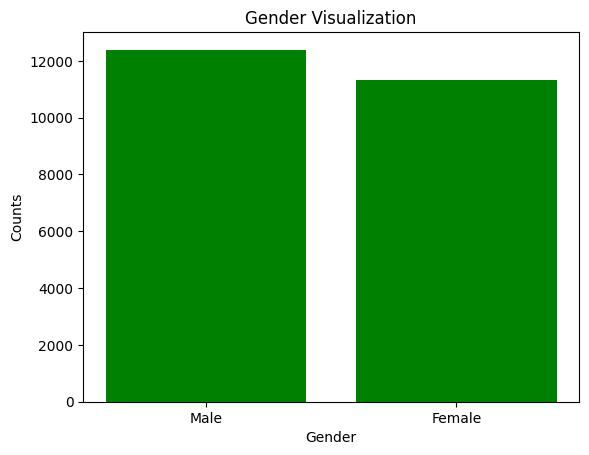

In [7]:
# Get gender category counts from the "gender" column
x = data["gender"].value_counts()

# Create a figure to visualize gender class distribution
plt.figure()

gender_labels = ["Male", "Female"]  # Labels for genders in the chart

# Create a bar chart to visualize the sample counts for each gender
plt.bar(gender_labels, x.values, color="green")

plt.title("Gender Visualization")  # Set chart title
plt.xlabel("Gender")  # Label X-axis
plt.ylabel("Counts")  # Label Y-axis

plt.show()  # Display the chart

### Displaying Sample Images with Gender Labels
This section creates a grid of images from the DataFrame, displaying the first 25 samples. It uses a dictionary to map gender indices to readable labels and presents each image along with its corresponding gender label in a 5x5 subplot.

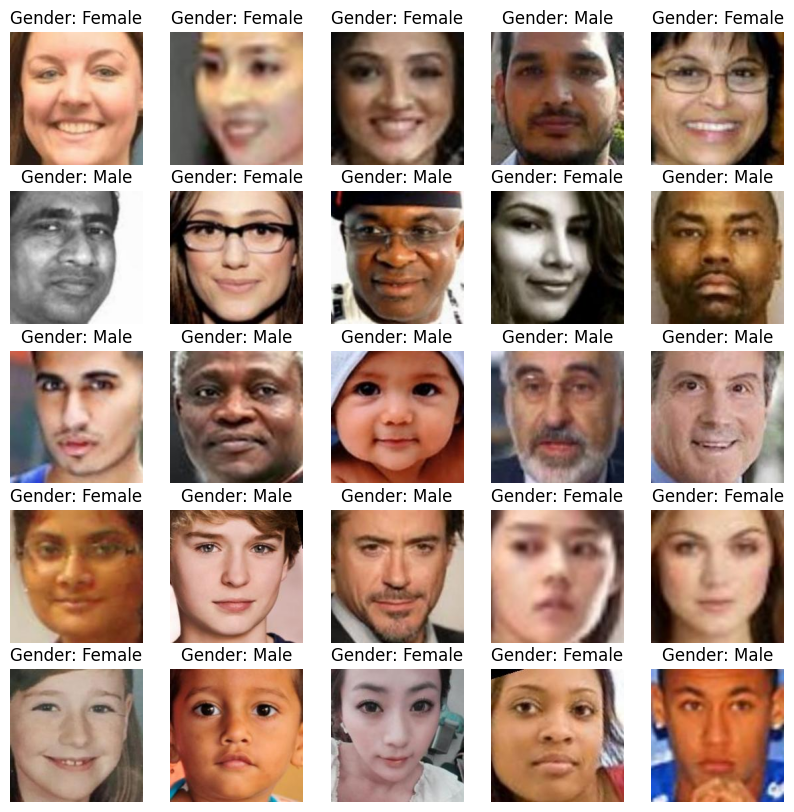

In [8]:
# Dictionary to map gender indices to readable labels
gender_dict = { 0: "Male", 1: "Female" }

# Set figure size to display a grid of images
plt.figure(figsize=(10, 10))

# Select the first 25 rows of the DataFrame "data" for visualization
files = data.iloc[0:25]

# Iterate through selected rows using itertuples to access indices and columns
for index, file, gender in files.itertuples():
    plt.subplot(5, 5, index + 1)  # Create a 5x5 subplot grid for each image

    img = load_img(file)  # Load the image
    img = np.array(img)  # Convert the image to a NumPy array

    plt.imshow(img)  # Display the image in the subplot

    plt.title(f"Gender: {gender_dict[gender]}")  # Set title with corresponding gender label

    plt.axis("off")  # Turn off axis labels and ticks

### Feature Extraction from Images
This function extracts features from a list of images by loading them in grayscale, resizing them to 128x128 pixels, and converting them into a NumPy array. The processed images are stored in a list, which is then reshaped to fit the model's input requirements before returning the final feature array.

In [9]:
def extract_features(images):
    features = []  # Initialize an empty list to store features

    # Iterate through the image list with a progress bar
    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale")  # Load the image in grayscale
        img = img.resize((128, 128))  # Resize the image to 128x128 pixels
        img = np.array(img)  # Convert image to a NumPy array

        features.append(img)  # Add the processed image to the features list

    # Convert the list to a NumPy array
    features = np.array(features)

    # Reshape the array to (number of images, 128x128, 1 channel)
    features = features.reshape(len(features), 128, 128, 1)

    return features  # Return the final feature array

### Extraction and Train-Test Split
This code snippet extracts image features and prepares the dataset for training by splitting it into training and testing sets.

In [10]:
# Extract image features from the 'image' column in 'data'
X = extract_features(data["image"])

# Convert the 'gender' column into a NumPy array
y = np.array(data["gender"])  # Reshape the labels to be 2D

# Split the data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalize the input data (pixel values will be between 0 and 1)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Convert the labels to one-hot encoding format
y_train = to_categorical(y_train, 2)
y_test = to_categorical(y_test, 2)

100%|██████████| 23708/23708 [00:24<00:00, 954.98it/s] 


### Defining and Compiling the Convolutional Neural Network Model
This code snippet defines a convolutional neural network (CNN) model using Keras. It includes multiple convolutional layers followed by pooling layers, and compiles the model with a specified loss function, optimizer, and evaluation metrics.

In [11]:
# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor="val_loss",  # Metric to monitor (can be "val_f1_score" if defined)
    patience=3,  # Number of epochs with no improvement before stopping training
    restore_best_weights=True  # Restore the best model weights during training
)

# Define the sequential model
model = Sequential([
    Input(shape=(128, 128, 1)),  # Input layer with shape (128, 128, 1)
    Conv2D(32, (3, 3), strides=2, padding="same", activation="relu"),  # First convolutional layer
    BatchNormalization(),  # Batch normalization layer
    MaxPooling2D((2, 2), padding="same"),  # First MaxPooling layer
    Dropout(0.3),  # Dropout to prevent overfitting

    Conv2D(64, (3, 3), strides=2, padding="same", activation="relu"),  # Second convolutional layer
    BatchNormalization(),  # Batch normalization layer
    MaxPooling2D((2, 2), padding="same"),  # Second MaxPooling layer
    Dropout(0.3),  # Dropout to prevent overfitting

    Conv2D(128, (3, 3), strides=2, padding="same", activation="relu"),  # Third convolutional layer
    BatchNormalization(),  # Batch normalization layer
    MaxPooling2D((2, 2), padding="same"),  # Third MaxPooling layer
    Dropout(0.4),  # Dropout to prevent overfitting

    Conv2D(128, (3, 3), strides=2, padding="same", activation="relu"),  # Fourth convolutional layer
    BatchNormalization(),  # Batch normalization layer
    MaxPooling2D((2, 2), padding="same"),  # Fourth MaxPooling layer
    Dropout(0.4),  # Dropout to prevent overfitting

    Flatten(),  # Flatten the output for the dense layer

    Dense(256, activation="relu", kernel_regularizer=l2(0.001)),  # Fully connected layer with 256 neurons
    BatchNormalization(),  # Batch normalization layer
    Dropout(0.5),  # Dropout to prevent overfitting

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),  # Fully connected layer with 128 neurons
    BatchNormalization(),  # Batch normalization layer
    Dropout(0.5),  # Dropout to prevent overfitting

    Dense(2, activation="sigmoid")  # Output layer for regression (no activation needed)
])

# Compile the model
model.compile(
    loss="binary_crossentropy",  # Loss function for binary classification
    optimizer="adam",  # Adam optimizer
    metrics=["f1_score"]  # F1 Score metric
)

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 4, 4, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 1, 1, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 1, 1, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 1, 1, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 309,378 (1.18 MB)

 Trainable params: 307,906 (1.17 MB)

 Non-trainable params: 1,472 (5.75 KB)

### Training the Convolutional Neural Network Model
This code snippet trains the previously defined convolutional neural network model using the extracted features (X) and gender labels (y). It specifies the batch size, number of epochs, and validation split for monitoring the model's performance during training.

In [12]:
# Train the model on the data
history = model.fit(x=X_train, y=y_train, batch_size=32, epochs=50, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)

Epoch 1/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 113s 205ms/step - f1_score: 0.5886 - loss: 1.1709 - val_f1_score: 0.6600 - val_loss: 0.8835
Epoch 2/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 140s 202ms/step - f1_score: 0.7323 - loss: 0.8109 - val_f1_score: 0.7923 - val_loss: 0.6204
Epoch 3/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 143s 205ms/step - f1_score: 0.7821 - loss: 0.6497 - val_f1_score: 0.8322 - val_loss: 0.5030
Epoch 4/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 104s 200ms/step - f1_score: 0.8070 - loss: 0.5428 - val_f1_score: 0.8290 - val_loss: 0.4516
Epoch 5/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 143s 203ms/step - f1_score: 0.8164 - loss: 0.4733 - val_f1_score: 0.8456 - val_loss: 0.4045
Epoch 6/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - f1_score: 0.8205 - loss: 0.4406 - val_f1_score: 0.8542 - val_loss: 0.3746
Epoch 7/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 145s 207ms/step - f1_score: 0.8324 - loss: 0.4011 - val_f1_score: 0.8619 - val_loss: 0.3362
Epoch 8/50
519/519 ━━━━━━━━━━━━━━━━━━━━ 141s 206ms/step - f1_score: 0.8367 -

### Evaluating the Model on the Test Set
This code evaluates the performance of the trained convolutional neural network model on the test set using the extracted features (X) and gender labels (y). It calculates the test loss and f1 score, then prints the f1 score to the console.

In [13]:
# Evaluate the model on the test set
test_loss, test_f1 = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss: {test_loss}")
print(f"Test f1 score: {test_f1}")

Test loss: 0.28741124272346497
Test f1 score: [0.89208245 0.8791536 ]


### Visualizing Training F1 Score and Loss
This code generates plots to visualize the training and validation f1 score and loss of the model over the epochs. It creates two subplots: one for f1 score and another for loss, providing insights into the model's performance during training.

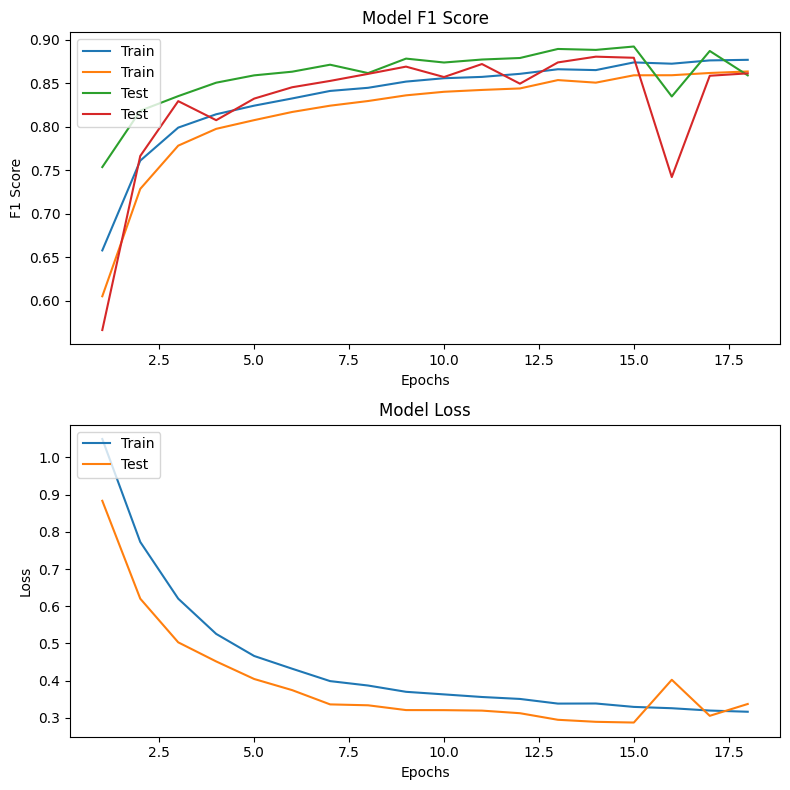

In [14]:
# Plot training f1 score and loss
epochs = range(1, len(history.history["f1_score"]) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# F1 score plot
ax1.plot(epochs, history.history["f1_score"], label="Train")
ax1.plot(epochs, history.history["val_f1_score"], label="Test")

ax1.set_title("Model F1 Score")
ax1.set_ylabel("F1 Score")
ax1.set_xlabel("Epochs")
ax1.legend(loc="upper left")

# Loss plot
ax2.plot(epochs, history.history["loss"], label="Train")
ax2.plot(epochs, history.history["val_loss"], label="Test")

ax2.set_title("Model Loss")
ax2.set_ylabel("Loss")
ax2.set_xlabel("Epochs")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Display Random Test Images with True and Predicted Class Labels
This code selects 20 random test images, displaying each image alongside its true and predicted class labels in a 4x5 grid.

In [15]:
# Predict class probabilities for each test image
y_pred = model.predict(X_test)

# Extract the predicted class index with the highest probability for each image
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels to class indices
y_test = np.argmax(y_test, axis=1)

223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step


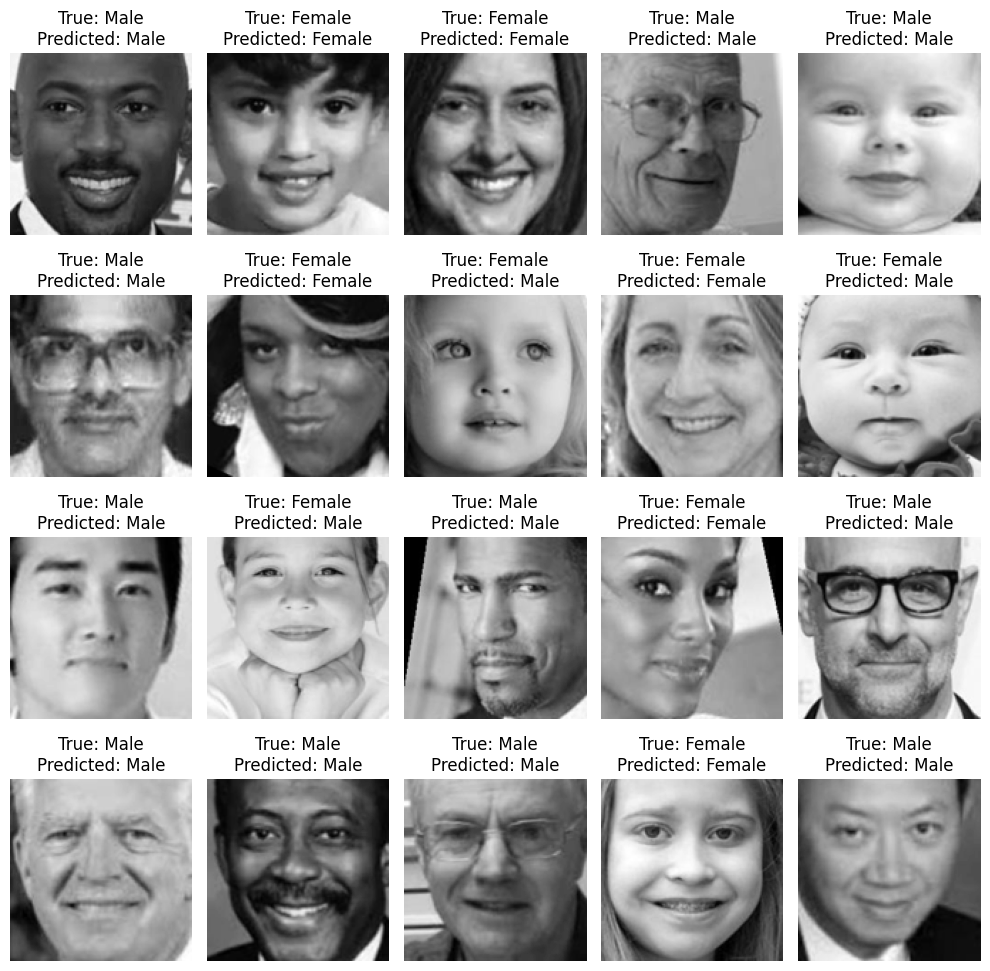

In [16]:
# Generate 20 unique random indices
random_indices = np.random.choice(X_test.shape[0], size=20, replace=False)

# Class names for each category
class_names = ["Male", "Female"]

# Display 20 randomly selected test images with true and predicted labels
plt.figure(figsize=(10, 10))

# Use the random indices
for i, idx in enumerate(random_indices):
    plt.subplot(4, 5, i + 1) # Create a 5x4 grid of subplots
    plt.imshow(X_test[idx].reshape(128, 128), cmap="gray")  # Display the image
    plt.title(f"True: {class_names[y_test[idx]]}\nPredicted: {class_names[y_pred_classes[idx]]}")  # Set title
    plt.axis("off")  # Turn off the axes

# Adjust layout for better visualization
plt.tight_layout()
plt.show()